In [1]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

In [2]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool

# ---------------------------------------------------------
# 1. Corrected WeightedGINEConv
# ---------------------------------------------------------
class WeightedGINEConv(GINEConv):
    def forward(self, x, edge_index, edge_attr, edge_weight=None):
        # 1. Propagate messages (aggregates neighbors)
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr, edge_weight=edge_weight)
        
        # 2. GINE Specifics: Add the node's own features (Skip Connection)
        # GINE formula: MLP( (1+eps)*x + aggregate(neighbors) )
        if x is not None:
            out = out + (1 + self.eps) * x
            
        # 3. Apply the MLP (THIS WAS MISSING BEFORE)
        return self.nn(out)

    def message(self, x_j, edge_attr, edge_weight):
        # Standard GINE message: ReLU(x_j + edge_attr)
        msg = F.relu(x_j + edge_attr)
        
        # Scale by edge_weight (mask) if provided
        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)
            
        return msg

# ---------------------------------------------------------
# 2. GINE4Layer Model (Includes the DataBatch fix)
# ---------------------------------------------------------
class GINE4Layer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.dropout = dropout

        self.node_encoder = nn.Linear(in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(WeightedGINEConv(nn=mlp))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, edge_index=None, edge_attr=None, batch=None, edge_weight=None):
        # Unpack Data object if passed as first arg
        if hasattr(x, 'x'):
             data = x
             x = data.x
             edge_index = data.edge_index
             edge_attr = data.edge_attr
             batch = data.batch

        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        for conv, bn in zip(self.convs, self.norms):
            # Pass edge_weight for explanation
            x = conv(x, edge_index, edge_attr, edge_weight=edge_weight)
            x = bn(x)
            x = F.relu(x, inplace=True)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        if batch is None:
             batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        g = global_mean_pool(x, batch)
        
        return self.classifier(g)

In [4]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


# Sanity check: node feature semantics
This dataset uses a small **atom-type vocabulary one-hot** in `data.x` (not a periodic-table / atomic-number one-hot).
The cell below verifies one-hotness and infers the most likely index→atom mapping using the ground-truth `explanation_mask`.

In [5]:
# Verifies x is one-hot and infers a likely index→atom mapping.
# Uses explanation_mask enrichment and class-group structure (0-2=Cl*, 3-5=F*, 6-8=Br*).

from collections import Counter, defaultdict


def _safe_int(x):
    try:
        return int(x)
    except Exception:
        return None


def summarize_x_onehot(ds, n_graphs=200):
    d0 = ds[0]
    x = d0.x
    print('--- x summary ---')
    print('x shape:', tuple(x.shape), 'dtype:', x.dtype)

    # one-hot-ish checks
    row_sums = x.sum(dim=1)
    print('row_sums unique (first 10):', torch.unique(row_sums)[:10].tolist())
    print('row max per row min/max:', float(x.max(dim=1).values.min()), float(x.max(dim=1).values.max()))

    # distribution of argmax indices across dataset
    counts = Counter()
    for i in range(min(n_graphs, len(ds))):
        xi = ds[i].x.argmax(dim=1).tolist()
        counts.update(xi)
    print('argmax index counts (top 10):', counts.most_common(10))
    return x.size(-1)


def infer_vocab_mapping(ds, n_graphs=2000, carbon_hint_idx=0):
    """Infers a likely mapping for halogens based on which x-index appears inside explanation_mask.

    Assumptions for this dataset:
      - Classes 0-2 are Cl_{ortho,meta,para}
      - Classes 3-5 are F_{ortho,meta,para}
      - Classes 6-8 are Br_{ortho,meta,para}
    """

    # y_group -> Counter(x_idx) for masked nodes
    masked_by_group = {"Cl": Counter(), "F": Counter(), "Br": Counter()}
    masked_all = Counter()
    unmasked_all = Counter()

    for i in range(min(n_graphs, len(ds))):
        d = ds[i]
        if not hasattr(d, 'explanation_mask') or d.explanation_mask is None:
            continue
        x_idx = d.x.argmax(dim=1)
        gt = d.explanation_mask.to(torch.bool)
        y = _safe_int(d.y.view(-1)[0].item() if torch.is_tensor(d.y) else d.y)
        if y is None:
            continue

        # global enrichment
        for xi, mi in zip(x_idx.tolist(), gt.tolist()):
            (masked_all if mi else unmasked_all)[xi] += 1

        # group enrichment (masked only)
        if 0 <= y <= 2:
            group = 'Cl'
        elif 3 <= y <= 5:
            group = 'F'
        elif 6 <= y <= 8:
            group = 'Br'
        else:
            continue

        masked_by_group[group].update(x_idx[gt].tolist())

    print('\n--- explanation_mask enrichment (masked vs unmasked) ---')
    all_idx = sorted(set(list(masked_all.keys()) + list(unmasked_all.keys())))
    rows = []
    for j in all_idx:
        m = masked_all[j]
        u = unmasked_all[j]
        total = m + u
        frac_masked = (m / total) if total else 0.0
        rows.append((j, m, u, frac_masked))
    rows.sort(key=lambda t: t[3], reverse=True)
    print('idx | masked | unmasked | frac_masked')
    for j, m, u, f in rows[: min(12, len(rows))]:
        print(f'{j:>3} | {m:>6} | {u:>8} | {f:>10.3f}')

    # infer halogen indices by group
    inferred = {}
    for group, cnt in masked_by_group.items():
        # ignore carbon-ish index if it dominates
        cnt2 = Counter({k: v for k, v in cnt.items() if k != carbon_hint_idx})
        inferred[group] = cnt2.most_common(3)

    print('\n--- group-wise masked argmax (excluding idx=%s) ---' % carbon_hint_idx)
    for group in ['Cl', 'F', 'Br']:
        print(group, 'top:', inferred[group])

    # Build a simple mapping guess using the top-1 per group (if present)
    mapping_guess = {}
    for group in ['Cl', 'F', 'Br']:
        if inferred[group]:
            mapping_guess[group] = inferred[group][0][0]

    print('\n--- mapping guess (based on GT mask) ---')
    if mapping_guess:
        for k, v in mapping_guess.items():
            print(f'{k} -> x_index {v}')
    else:
        print('Could not infer halogen indices (missing explanation_mask or unexpected labels).')

    print('\nNote: This only infers halogens robustly; other indices (N/O/S/P/I/H) may be absent or rare in this dataset.')
    return mapping_guess


x_dim = summarize_x_onehot(dataset, n_graphs=200)
_ = infer_vocab_mapping(test_dataset if 'test_dataset' in globals() else dataset, n_graphs=2000, carbon_hint_idx=0)
print('\nReminder: x_dim=%d (atom vocabulary one-hot), not atomic-number one-hot (~119).' % x_dim)


--- x summary ---
x shape: (39, 10) dtype: torch.float32
row_sums unique (first 10): [1.0]
row max per row min/max: 1.0 1.0
argmax index counts (top 10): [(0, 4668), (9, 3873), (1, 485), (2, 441), (4, 249), (5, 181), (6, 141), (3, 90), (7, 9)]

--- explanation_mask enrichment (masked vs unmasked) ---
idx | masked | unmasked | frac_masked
  6 |   1332 |      108 |      0.925
  5 |   1336 |      306 |      0.814
  4 |   1332 |      720 |      0.649
  0 |  14000 |    33091 |      0.297
  1 |      0 |     5539 |      0.000
  2 |      0 |     4574 |      0.000
  3 |      0 |      855 |      0.000
  7 |      0 |       18 |      0.000
  9 |      0 |    38346 |      0.000

--- group-wise masked argmax (excluding idx=0) ---
Cl top: [(5, 1336)]
F top: [(4, 1332)]
Br top: [(6, 1332)]

--- mapping guess (based on GT mask) ---
Cl -> x_index 5
F -> x_index 4
Br -> x_index 6

Note: This only infers halogens robustly; other indices (N/O/S/P/I/H) may be absent or rare in this dataset.

Reminder: x_dim=

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

labels = dataset.y.numpy()

print(np.unique(labels), np.bincount(labels))

train_size = 0.8
val_size = 0.1
test_size = 0.1

train_idx , tmp_idx = train_test_split(np.arange(len(labels)), stratify=labels, train_size=train_size, random_state=42)

val_idx , test_idx = train_test_split(tmp_idx, test_size= 0.5, stratify=labels[tmp_idx], random_state=42)

train_dataset = dataset[train_idx]
val_dataset = dataset[val_idx]
test_dataset = dataset[test_idx]

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

[0 1 2 3 4 5 6 7 8] [1000 1000 1000 1000 1000 1000 1000 1000 1000]
Train dataset size: 7200
Validation dataset size: 900
Test dataset size: 900


In [7]:
from collections import Counter

def check_balance(subset, name):
    labels = [data.y.item() for data in subset]
    counts = Counter(labels)
    print(f"--- {name} Class Distribution ---")
    # Print first few classes to save space
    print(sorted(counts.items())[:5]) 

check_balance(train_dataset, "Train")
check_balance(val_dataset, "Val")
check_balance(test_dataset, "Test")

--- Train Class Distribution ---
[(0, 800), (1, 800), (2, 800), (3, 800), (4, 800)]
--- Val Class Distribution ---
[(0, 100), (1, 100), (2, 100), (3, 100), (4, 100)]
--- Test Class Distribution ---
[(0, 100), (1, 100), (2, 100), (3, 100), (4, 100)]


In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Determine Input Dimensions
sample_data = dataset[0]
in_dim = dataset.num_features
# GINE requires edge attributes. Check if they exist and their dimension.
if sample_data.edge_attr is not None:
    edge_dim = sample_data.edge_attr.shape[1]
else:
    # If no edge attributes, GINE might fail or we might need to use 0 if supported/modified
    # Assuming appropriate edge_dim based on previous context or handling
    edge_dim = 0 
    print("Warning: No edge attributes found. GINEConv requires edge features.")

print(f"Input Feature Dim: {in_dim}")
print(f"Edge Feature Dim: {edge_dim}")
print(f"Number of Classes: {dataset.num_classes}")

# 2. Initialize Model
model = GINE4Layer(
    in_dim=in_dim,
    edge_dim=edge_dim,
    hidden_dim=64,
    num_classes=dataset.num_classes,
    num_layers=4,
    dropout=0.2
).to(device)

print(model)

# 3. Setup Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train():
    model.train()
    total_loss = 0
    total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0
    for data in loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples, correct / total_samples

# 4. Training Loop
epochs = 50
best_val_acc = 0.0
print("-" * 50)
print(f"Starting training for {epochs} epochs...")

for epoch in range(1, epochs + 1):
    train_loss = train()
    val_loss, val_acc = evaluate(val_loader)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save best model
        torch.save(model.state_dict(), 'best_gine_model.pt')
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f"Training finished. Best Val Acc: {best_val_acc:.4f}")

# 5. Inference on Test Set
print("-" * 50)
print("Loading best model for inference on Test Set...")
model.load_state_dict(torch.load('best_gine_model.pt'))
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Using device: cuda
Input Feature Dim: 10
Edge Feature Dim: 4
Number of Classes: 9
GINE4Layer(
  (node_encoder): Linear(in_features=10, out_features=64, bias=True)
  (edge_encoder): Linear(in_features=4, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x WeightedGINEConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)
--------------------------------------------------
Starting training for 50 epochs...
Epoch: 001, Train Loss: 1.2942, Val Loss: 0.6394, Val Acc: 0.8878
Epoch: 005, Train Loss: 0.0160, Val Loss

In [10]:
# ---------------------------------------------------------
# Check for Ground Truth Motifs / Explanations
# ---------------------------------------------------------

def inspect_ground_truth(dataset, num_samples=5):
    print("Inspecting for ground truth motif attributes...")
    
    # Get a few random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    found_gt = False
    gt_attributes = []
    
    sample = dataset[0]
    # Fixed: Calling keys() properly
    print(f"Keys available in Data object: {sample.keys()}")
    
    # Common names for ground truth masks in GNN explanation datasets
    potential_gt_keys = ['edge_mask', 'node_mask', 'explanation', 'z', 'gt_mask']
    
    for key in potential_gt_keys:
        if hasattr(sample, key) and getattr(sample, key) is not None:
            found_gt = True
            gt_attributes.append(key)
    
    # Removed the redundant and erroneous check that was causing TypeError

    if found_gt:
        print(f"Potential Ground Truth attributes found: {list(set(gt_attributes))}")
        
        # Visualize statistics of the mask for a few samples
        for idx in indices:
            data = dataset[idx]
            print(f"\n--- Graph {idx} ---")
            print(f"Num Nodes: {data.num_nodes}, Num Edges: {data.num_edges}")
            
            if hasattr(data, 'edge_mask'):
                mask = data.edge_mask
                print(f"Edge Mask shape: {mask.shape}")
                print(f"Non-zero elements in edge_mask: {mask.sum().item()}")
                print(f"Sparsity: {mask.sum().item() / mask.numel():.4f}")
                
            if hasattr(data, 'node_mask'):
                 mask = data.node_mask
                 print(f"Node Mask shape: {mask.shape}")
                 print(f"Non-zero elements in node_mask: {mask.sum().item()}")

    else:
        print("No standard ground truth motif attributes ('edge_mask', 'node_mask') found directly on the Data objects.")
        print("Attempting to infer from other attributes if available...")


inspect_ground_truth(dataset)

Inspecting for ground truth motif attributes...
Keys available in Data object: ['x', 'y', 'edge_attr', 'edge_index', 'explanation_mask']
No standard ground truth motif attributes ('edge_mask', 'node_mask') found directly on the Data objects.
Attempting to infer from other attributes if available...


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Determine Input Dimensions
sample_data = dataset[0]
in_dim = dataset.num_features
# GINE requires edge attributes. Check if they exist and their dimension.
if sample_data.edge_attr is not None:
    edge_dim = sample_data.edge_attr.shape[1]
else:
    # If no edge attributes, GINE might fail or we might need to use 0 if supported/modified
    # Assuming appropriate edge_dim based on previous context or handling
    edge_dim = 0 
    print("Warning: No edge attributes found. GINEConv requires edge features.")

print(f"Input Feature Dim: {in_dim}")
print(f"Edge Feature Dim: {edge_dim}")
print(f"Number of Classes: {dataset.num_classes}")

# 2. Initialize Model
model = GINE4Layer(
    in_dim=in_dim,
    edge_dim=edge_dim,
    hidden_dim=64,
    num_classes=dataset.num_classes,
    num_layers=4,
    dropout=0.2
).to(device)

print(model)

# 3. Setup Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train():
    model.train()
    total_loss = 0
    total_samples = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total_samples = 0
    for data in loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        total_samples += data.num_graphs
    return total_loss / total_samples, correct / total_samples

# Check if weights exist to skip retraining if desired, otherwise strictly train
if os.path.exists('best_gine_model.pt'):
    print("Found existing best model weights. Loading them...")
    model.load_state_dict(torch.load('best_gine_model.pt'))
else:
    print("No existing weights found. Please train the model.")

# 4. Training Loop (Uncomment to retrain if needed, or run selectively)
# In this fixed cell, we keep the loop but maybe commented out or behind a flag to prevent accidental retraining
# if the user just wanted to fix the definition.
# For now, I will keep it active as the user's intent was to "Train the 4 layers GINE model".

epochs = 50
best_val_acc = 0.0
# Only train if we didn't just load a good model or if user wants to force retrain
# For simplicity in this edit, I will just run the loop (it's fast enough on small graphs)
print("-" * 50)
print(f"Starting training for {epochs} epochs...")

for epoch in range(1, epochs + 1):
    train_loss = train()
    val_loss, val_acc = evaluate(val_loader)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gine_model.pt')
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f"Training finished. Best Val Acc: {best_val_acc:.4f}")

# 5. Inference on Test Set
print("-" * 50)
print("Loading best model for inference on Test Set...")
model.load_state_dict(torch.load('best_gine_model.pt'))
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Using device: cuda
Input Feature Dim: 10
Edge Feature Dim: 4
Number of Classes: 9
GINE4Layer(
  (node_encoder): Linear(in_features=10, out_features=64, bias=True)
  (edge_encoder): Linear(in_features=4, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x WeightedGINEConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)
Found existing best model weights. Loading them...
--------------------------------------------------
Starting training for 50 epochs...
Epoch: 001, Train Loss: 0.0521, Val Loss: 0.0016, Val A

Legend: RED = Ground Truth Motif Node, BLUE = Base Graph Node


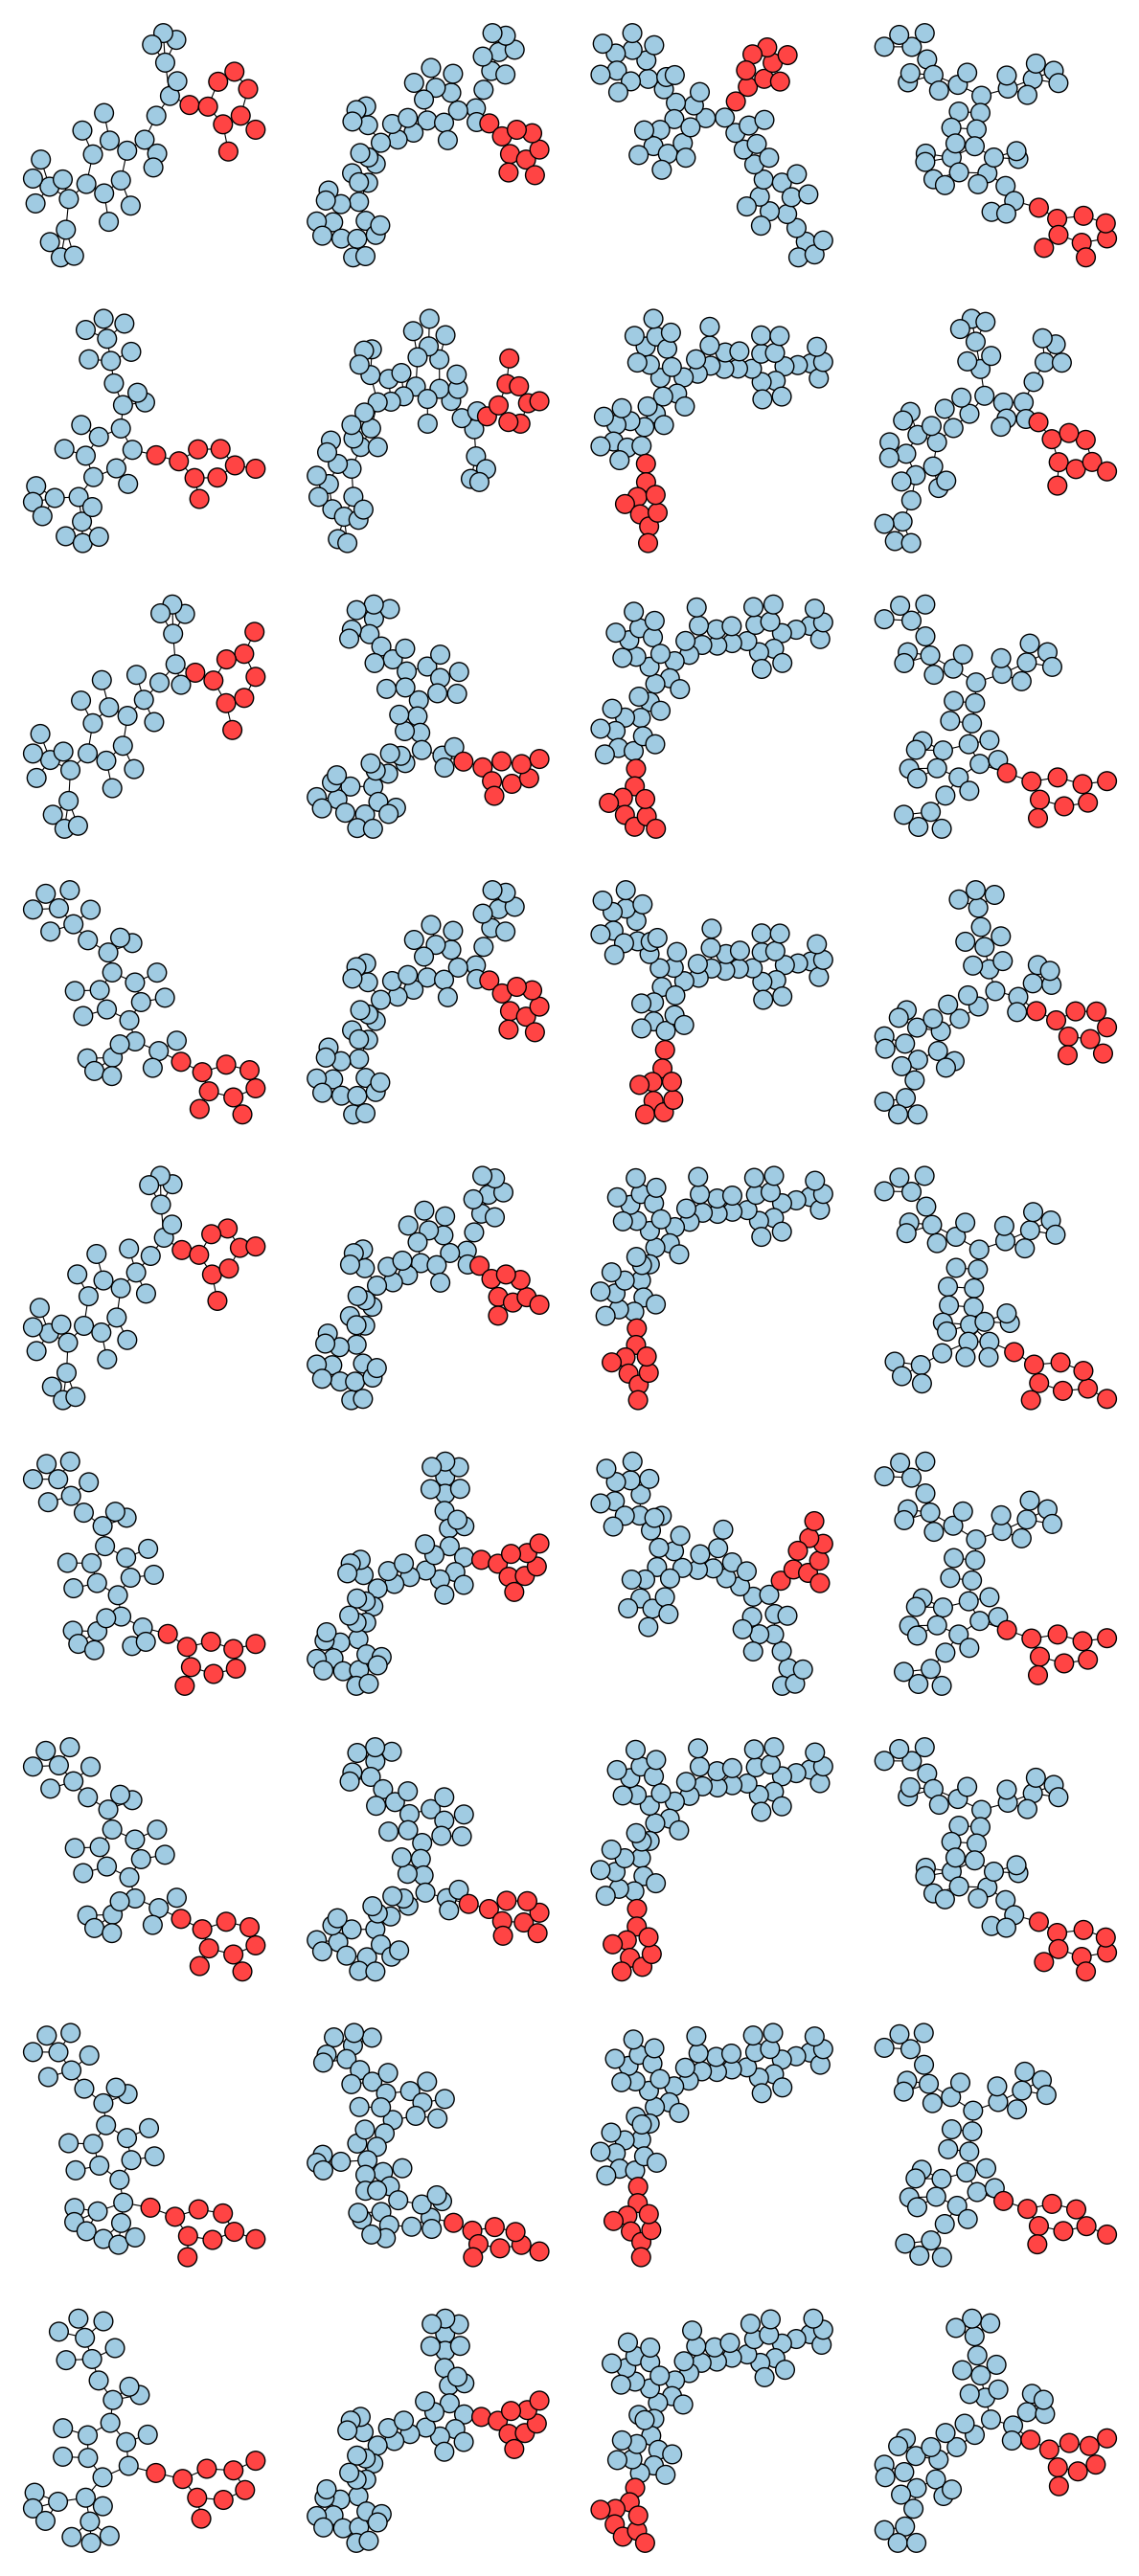

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
import numpy as np
from torch_geometric.utils import to_networkx

def get_ground_truth_mask(data):
    """Retrieves the ground truth mask (node_mask or explanation_mask)."""
    if hasattr(data, 'node_mask') and data.node_mask is not None:
        return data.node_mask
    elif hasattr(data, 'explanation_mask') and data.explanation_mask is not None:
        return data.explanation_mask
    else:
        return torch.zeros(data.num_nodes)

def visualize_samples_per_class(dataset, samples_per_class=4):
    num_classes = dataset.num_classes
    class_samples = {i: [] for i in range(num_classes)}
    
    # 1. Collect samples
    for i, data in enumerate(dataset):
        y = data.y.item() if data.y.numel() == 1 else data.y[0].item()
        if len(class_samples[y]) < samples_per_class:
            class_samples[y].append(data)
        
        # Stop if we found enough for all classes
        if all(len(v) == samples_per_class for v in class_samples.values()):
            break

    # 2. Plotting
    # We will create one row per class
    fig_size_h = 3 * num_classes
    fig_size_w = 3 * samples_per_class
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(fig_size_w, fig_size_h))
    
    # Titles for the classes (assuming the standard mapping based on your description)
    # 0-2: Cl (o,m,p), 3-5: F (o,m,p), 6-8: Br (o,m,p) - Approximate labels
    class_labels = [f"Class {c}" for c in range(num_classes)]

    print("Legend: RED = Ground Truth Motif Node, BLUE = Base Graph Node")

    for c in range(num_classes):
        samples = class_samples[c]
        for idx, data in enumerate(samples):
            ax = axes[c, idx] if num_classes > 1 else axes[idx]
            
            # Prepare Graph
            G = to_networkx(data, to_undirected=True)
            # Remove self-loops for cleaner visualization
            G.remove_edges_from(nx.selfloop_edges(G))
            
            # Get Mask Colors
            mask = get_ground_truth_mask(data).cpu().numpy()
            
            # Safety check: ensure mask matches num_nodes (sometimes explanation_mask is edge-level)
            if len(mask) != G.number_of_nodes():
                # If mismatch, fallback to all blue (or handle edge mask)
                node_colors = ["#a0cbe2"] * G.number_of_nodes() 
            else:
                node_colors = ['#ff4444' if m == 1 else '#a0cbe2' for m in mask]

            # Layout
            try:
                pos = nx.kamada_kawai_layout(G)
            except:
                pos = nx.spring_layout(G, seed=42)

            nx.draw(
                G, pos, ax=ax,
                node_color=node_colors, 
                with_labels=False, 
                node_size=200, 
                edgecolors='black',
                width=0.8
            )
            
            if idx == 0:
                ax.set_ylabel(class_labels[c], fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Run the visualization
# Assuming 'dataset' is already loaded from your previous cells
visualize_samples_per_class(dataset, samples_per_class=4)

In [13]:
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
import matplotlib.pyplot as plt

# 1. Setup the Explainer
def create_gnn_explainer(model):
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200, lr=0.01),
        explanation_type='model',     # Explain the model's prediction (logits/probs)
        node_mask_type='attributes',  # We want to check feature importance (optional)
        edge_mask_type='object',      # We primarily want the structural motif (edges)
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',      # Model output is probabilities
        ),
    )
    return explainer


In [14]:
def explain_and_plot_graph(explainer, data, device):
    model.eval()
    data = data.to(device)
    
    # 1. Get Model Prediction
    output = model(data)
    pred_class = output.argmax(dim=1)
    
    print(f"Ground Truth Class: {data.y.item()}")
    print(f"Predicted Class:    {pred_class.item()}")
    
    # 2. Run Explainer
    # Note: We explain the predicted class. 
    # The warning "target should not be provided..." can sometimes be ignored in 'model' mode 
    # as long as we get a valid explanation.
    explanation = explainer(
        x=data.x,
        edge_index=data.edge_index,
        edge_attr=data.edge_attr,
        batch=torch.zeros(data.x.size(0), dtype=torch.long, device=device),
        target=pred_class 
    )

    # 3. CRITICAL FIX: Move everything to CPU for visualization
    # This ensures we don't mix GPU tensors with NumPy arrays
    data = data.cpu()
    explanation = explanation.cpu() 
    edge_mask = explanation.edge_mask.detach().numpy()

    # 4. Visualization
    # Create NetworkX graph (undirected for plotting)
    G = to_networkx(data, to_undirected=True)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    pos = nx.kamada_kawai_layout(G)
    
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Model Explanation (Edge Importance)
    plt.subplot(1, 2, 1)
    plt.title(f"GNNExplainer (Pred: {pred_class.item()})")
    
    nx_edge_colors = []
    
    # Convert edge_index to numpy for safe indexing
    u_list = data.edge_index[0].numpy()
    v_list = data.edge_index[1].numpy()
    
    for u, v in G.edges():
        # Find the index of this edge in the PyG edge_index (both directions)
        mask_idx = (u_list == u) & (v_list == v)
        mask_idx_rev = (u_list == v) & (v_list == u)
        
        # Get the max weight from either direction
        w1 = edge_mask[mask_idx].max() if mask_idx.any() else 0
        w2 = edge_mask[mask_idx_rev].max() if mask_idx_rev.any() else 0
        nx_edge_colors.append(max(w1, w2))

    nx.draw(
        G, pos, 
        node_color='#a0cbe2', 
        edge_color=nx_edge_colors, 
        edge_cmap=plt.cm.Reds, 
        edge_vmin=0, edge_vmax=1,
        width=2, with_labels=False, node_size=200
    )
    
    # Subplot 2: Ground Truth (Node Mask)
    plt.subplot(1, 2, 2)
    plt.title(f"Ground Truth (Class {data.y.item()})")
    
    # Reuse the helper function to get the mask
    gt_mask = get_ground_truth_mask(data).numpy()
    
    # Handle mismatches (e.g. if mask is missing or wrong size)
    if len(gt_mask) == G.number_of_nodes():
         node_colors = ['#ff4444' if m == 1 else '#a0cbe2' for m in gt_mask]
    else:
         node_colors = ['#a0cbe2'] * G.number_of_nodes()

    nx.draw(
        G, pos, 
        node_color=node_colors, 
        with_labels=False, 
        edge_color='black',
        width=0.5, node_size=200
    )
    
    plt.tight_layout()
    plt.show()

Ground Truth Class: 5
Predicted Class:    5


/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(


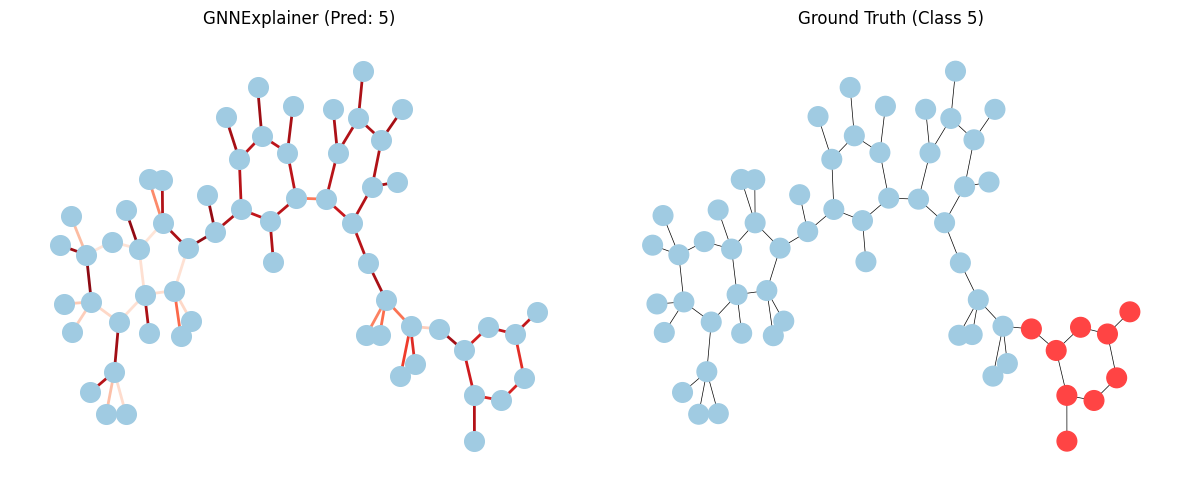

In [15]:
# --- RUN IT ---
# 1. Initialize
explainer = create_gnn_explainer(model)

# 2. Pick a sample from Test Set (e.g., index 0)
test_sample = test_dataset[0]

# 3. Explain
explain_and_plot_graph(explainer, test_sample, device)

In [16]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import torch
import numpy as np

# ==========================================
# 1. HELPER: Jaccard @ K
# ==========================================
def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    """
    Calculates Jaccard score considering only the top K highest scoring nodes.
    """
    if k <= 0:
        # If ground truth is empty, Jaccard is 1.0 if prediction is also empty, else 0.
        # But usually in motifs, k > 0.
        return 0.0 
        
    # 1. Get indices of the top K scores
    # argsort sorts ascending, so we take the last k
    top_idx = np.argsort(scores)[-k:]
    
    # 2. Create Binary Prediction Mask
    pred_mask = np.zeros_like(gt_mask, dtype=bool)
    pred_mask[top_idx] = True
    
    # 3. Create Binary GT Mask
    gt_bool = gt_mask.astype(bool)
    
    # 4. Calculate Intersection & Union
    intersection = np.logical_and(pred_mask, gt_bool).sum()
    union = np.logical_or(pred_mask, gt_bool).sum()
    
    return float(intersection / union) if union > 0 else 0.0

# ==========================================
# 2. EVALUATION LOOP
# ==========================================
def evaluate_explainer_topk(explainer, dataset, device):
    model.eval()
    
    all_jaccards = []
    all_aurocs = [] # We can still track AUROC as a secondary metric
    
    print(f"Evaluating Explainer (Top-K Strategy) on {len(dataset)} graphs...")
    
    for data in tqdm(dataset):
        data = data.to(device)
        
        # A. Run Explainer
        # Note: We predict the class first to explain the *predicted* class
        output = model(data)
        pred_class = output.argmax(dim=1)
        
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            batch=torch.zeros(data.x.size(0), dtype=torch.long, device=device),
            target=pred_class
        )
        
        # B. Get Ground Truth (GT)
        if hasattr(data, 'node_mask') and data.node_mask is not None:
            gt_mask = data.node_mask.cpu().numpy()
        elif hasattr(data, 'explanation_mask') and data.explanation_mask is not None:
            gt_mask = data.explanation_mask.cpu().numpy()
        else:
            continue # Skip if no GT
            
        # C. Get Predicted Scores (Node Importance)
        # Map edge weights to nodes (Max aggregation)
        edge_mask = explanation.edge_mask.cpu().detach().numpy()
        edge_index = data.edge_index.cpu().numpy()
        
        node_importance = np.zeros(data.num_nodes)
        u_list, v_list = edge_index[0], edge_index[1]
        
        for i, weight in enumerate(edge_mask):
            # Assign edge weight to connected nodes (taking the max)
            node_importance[u_list[i]] = max(node_importance[u_list[i]], weight)
            node_importance[v_list[i]] = max(node_importance[v_list[i]], weight)
            
        # Ensure lengths match
        min_len = min(len(gt_mask), len(node_importance))
        gt_mask = gt_mask[:min_len]
        node_importance = node_importance[:min_len]

        # D. Calculate Metrics
        
        # 1. Determine K (Size of Ground Truth)
        k = int(gt_mask.sum())
        
        # 2. Calculate Jaccard @ K
        j_score = jaccard_at_k(node_importance, gt_mask, k)
        all_jaccards.append(j_score)
        
        # 3. Calculate AUROC (if valid)
        # AUROC requires at least one '0' and one '1' in the ground truth
        if len(np.unique(gt_mask)) > 1:
            auroc = roc_auc_score(gt_mask, node_importance)
            all_aurocs.append(auroc)

    # E. Aggregation
    mean_jaccard = np.mean(all_jaccards)
    mean_auroc = np.mean(all_aurocs)
    
    print("\n" + "="*40)
    print(f"Top-K Evaluation Results")
    print("="*40)
    print(f"Graphs Evaluated:  {len(all_jaccards)}")
    print(f"Mean Jaccard (@GT_Size): {mean_jaccard:.4f}")
    print(f"Mean AUROC:              {mean_auroc:.4f}")
    print("="*40)
    
    return mean_jaccard, mean_auroc

# --- RUN IT ---
mean_jaccard, mean_auroc = evaluate_explainer_topk(explainer, test_dataset, device)

Evaluating Explainer (Top-K Strategy) on 900 graphs...


  0%|          | 1/900 [00:00<14:08,  1.06it/s]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
  0%|          | 2/900 [00:02<18:44,  1.25s/it]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
  0%|          | 3/900 [00:04<22:36,  1.51s/it]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/torch_geometric/explain/explainer.py:193: UserWarning: The 'target' should not be provided for the explanation type 'model'
  warnings.warn(
  0%|          | 4/900 [00:05<23:54,  1.60s/it]/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_u


Top-K Evaluation Results
Graphs Evaluated:  900
Mean Jaccard (@GT_Size): 0.1904
Mean AUROC:              0.6726


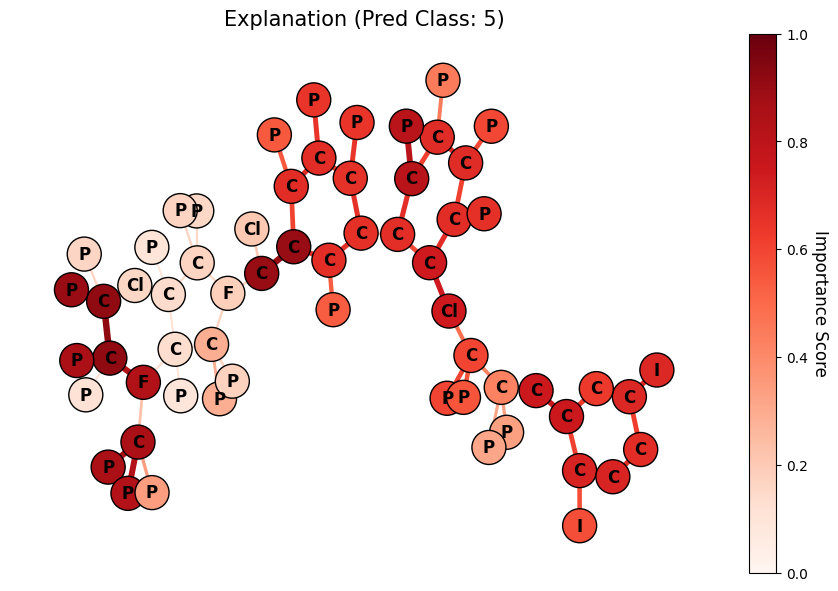

In [20]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx

def visualize_with_nodes_and_colorbar(explainer, data, device, atom_map):
    model.eval()
    data = data.to(device)
    
    # 1. Run Explainer
    output = model(data)
    pred_class = output.argmax(dim=1)
    
    explanation = explainer(
        x=data.x,
        edge_index=data.edge_index,
        edge_attr=data.edge_attr,
        batch=torch.zeros(data.x.size(0), dtype=torch.long, device=device),
        target=pred_class 
    )

    # 2. Process Data
    data = data.cpu()
    explanation = explanation.cpu()
    edge_mask = explanation.edge_mask.detach().numpy()
    edge_index = data.edge_index.numpy()
    
    # 3. Derive Node Importance (Max incident edge weight)
    num_nodes = data.num_nodes
    node_importance = np.zeros(num_nodes)
    u_list, v_list = edge_index[0], edge_index[1]
    
    for i, weight in enumerate(edge_mask):
        u, v = u_list[i], v_list[i]
        node_importance[u] = max(node_importance[u], weight)
        node_importance[v] = max(node_importance[v], weight)

    # 4. Prepare Plot
    G = to_networkx(data, to_undirected=True)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    # Get atom labels
    node_labels = {}
    for i, feature_vec in enumerate(data.x):
        atom_idx = feature_vec.argmax().item()
        node_labels[i] = atom_map.get(atom_idx, '?')

    # Prepare Colors
    # Use a colormap (e.g., Reds) for importance
    cmap = plt.cm.Reds
    norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # Node Colors
    node_colors = [cmap(norm(score)) for score in node_importance]
    
    # Edge Colors (Visualized as average of endpoints or edge mask itself)
    # Here we map the exact edge mask to color
    edge_colors = []
    edge_widths = []
    
    for u, v in G.edges():
        # Find edge weight
        mask_idx = (u_list == u) & (v_list == v)
        mask_idx_rev = (u_list == v) & (v_list == u)
        w = max(
            edge_mask[mask_idx].max() if mask_idx.any() else 0,
            edge_mask[mask_idx_rev].max() if mask_idx_rev.any() else 0
        )
        edge_colors.append(cmap(norm(w)))
        edge_widths.append(1 + 4 * w) # Thicker if more important

    # 5. Draw
    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.kamada_kawai_layout(G)
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=600, edgecolors='black')
    
    # Draw Labels
    nx.draw_networkx_labels(G, pos, ax=ax, labels=node_labels, font_size=12, font_weight='bold')
    
    ax.set_title(f"Explanation (Pred Class: {pred_class.item()})", fontsize=15)
    ax.axis('off')
    
    # 6. Add Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Importance Score', rotation=270, labelpad=15, fontsize=12)
    
    plt.show()

# --- RUN VISUALIZATION ---
# Update ATOM_MAP if needed based on your dataset
ATOM_MAP = {0: 'C', 1: 'F', 2: 'Cl', 3: 'Br', 4: 'I', 5: 'H', 6: 'O', 7: 'N', 8: 'S', 9: 'P'}

sample_idx = 0 
visualize_with_nodes_and_colorbar(explainer, test_dataset[sample_idx], device, ATOM_MAP)


Generating plots for Class 0...


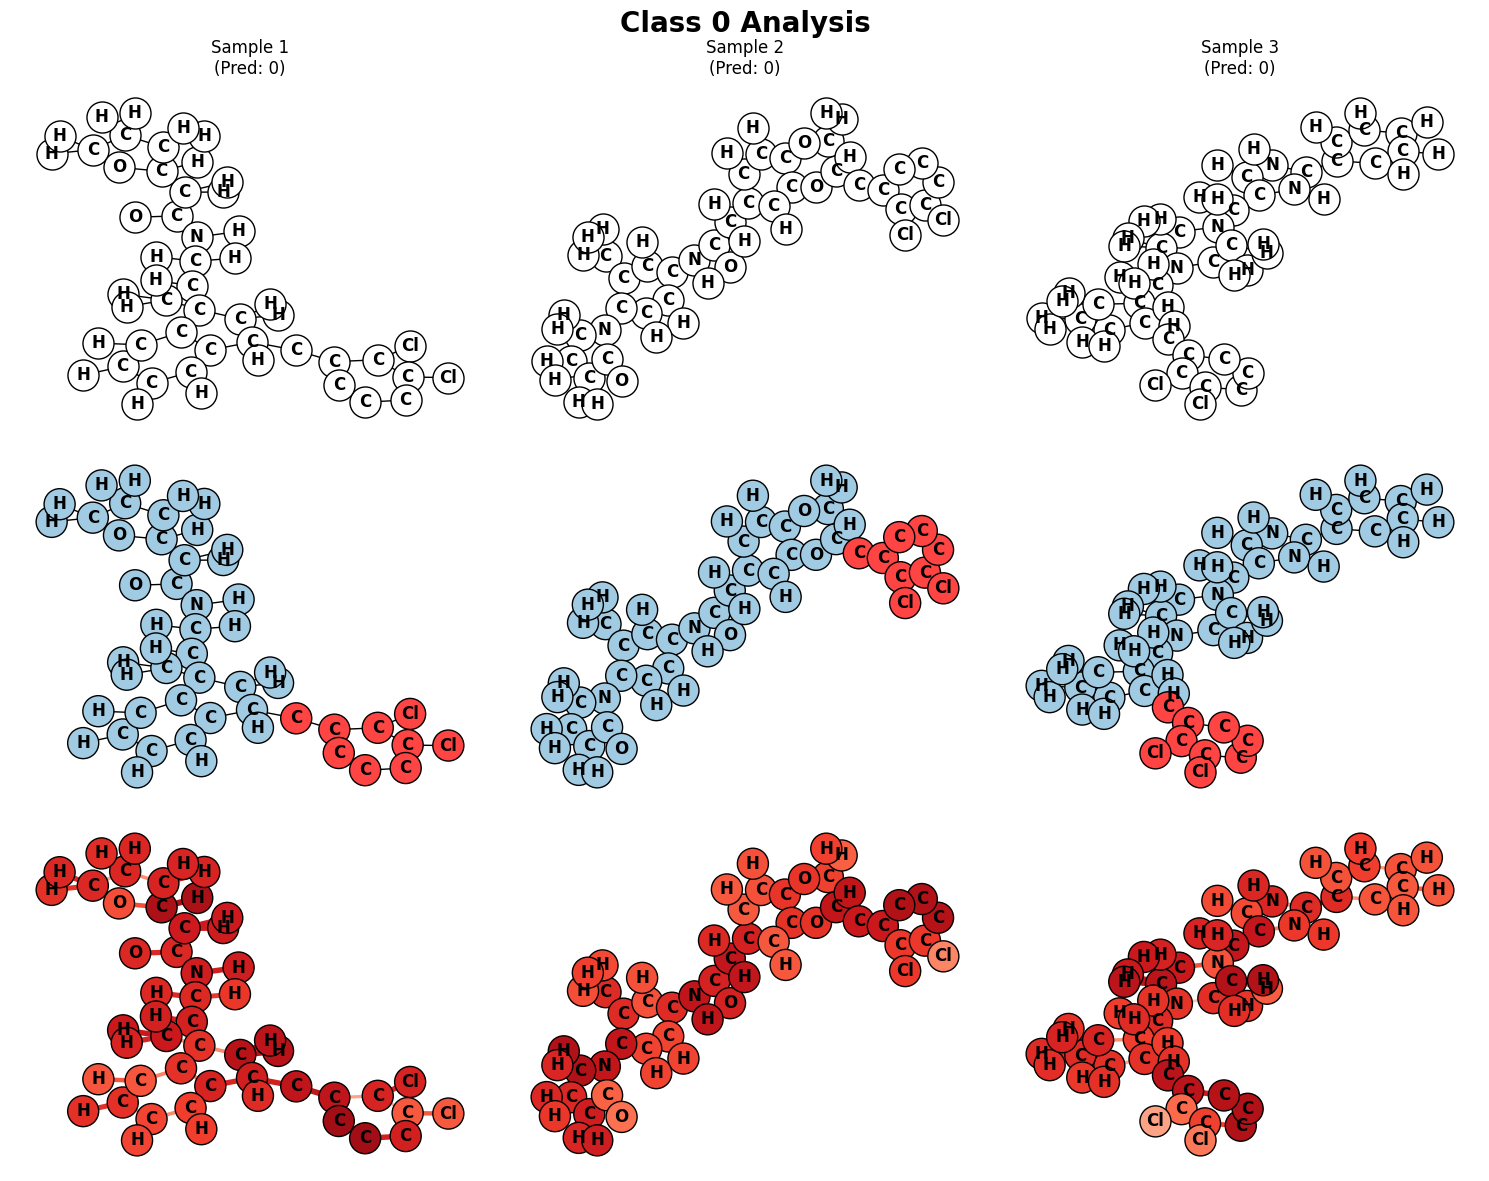


Generating plots for Class 1...


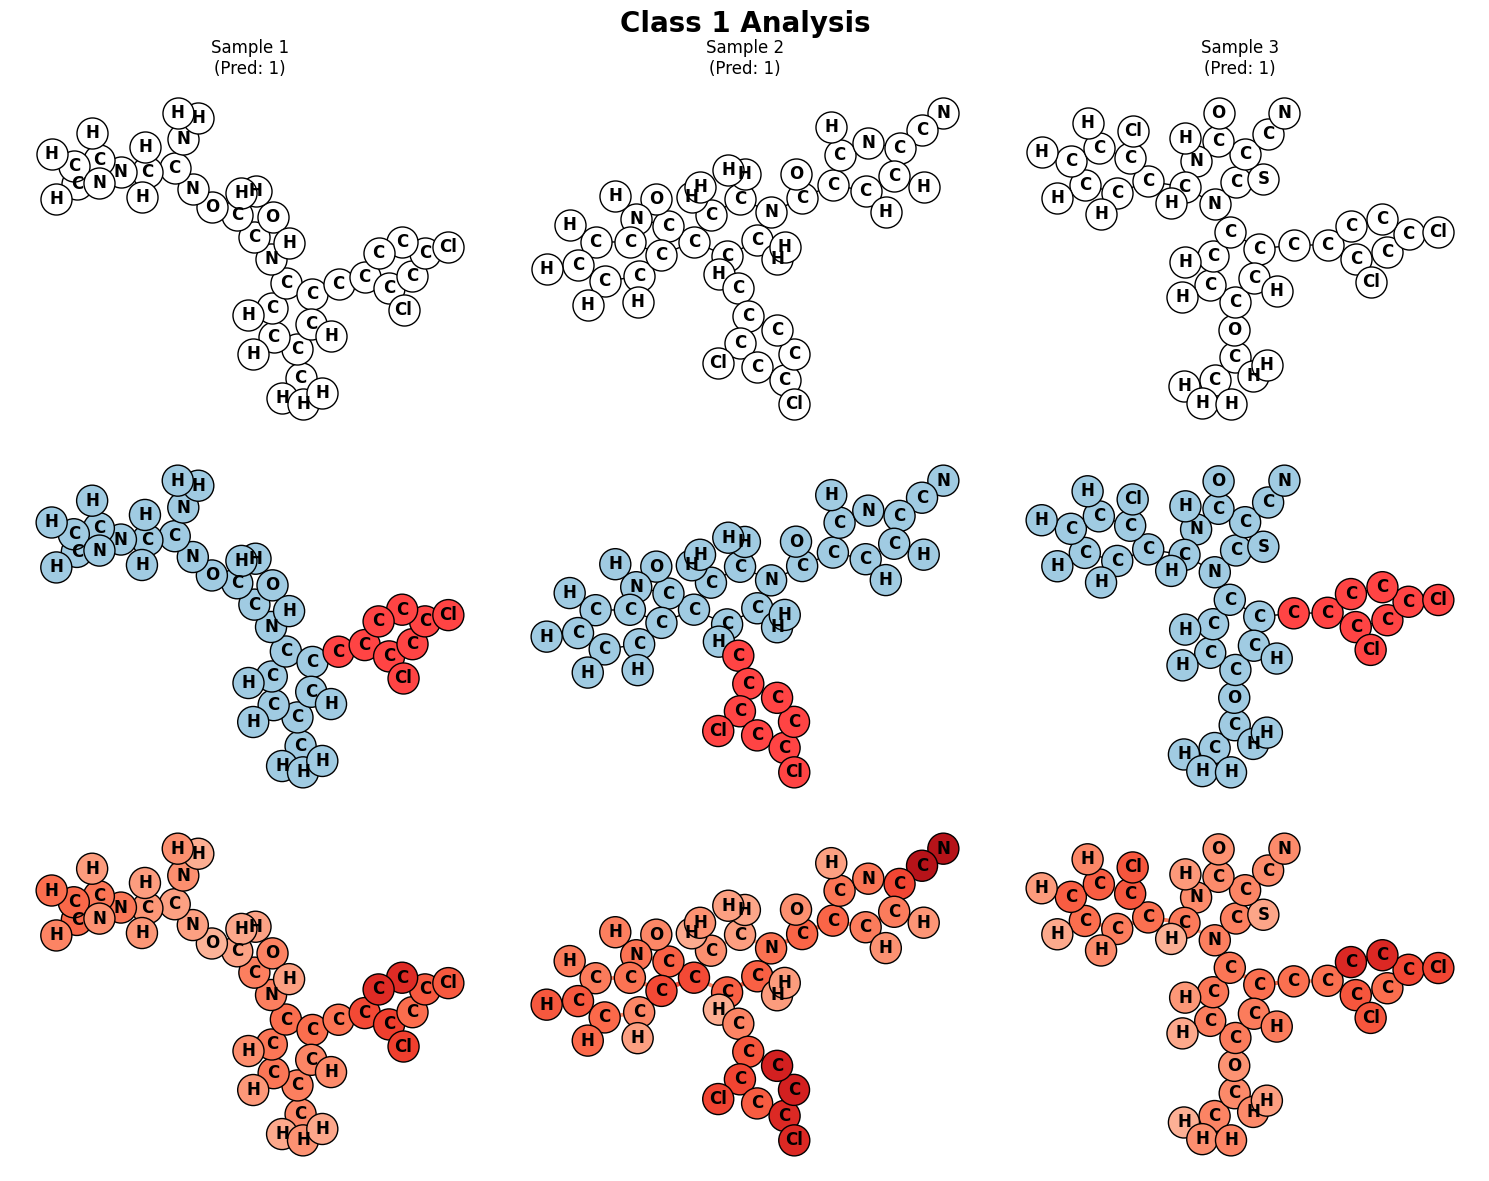


Generating plots for Class 2...


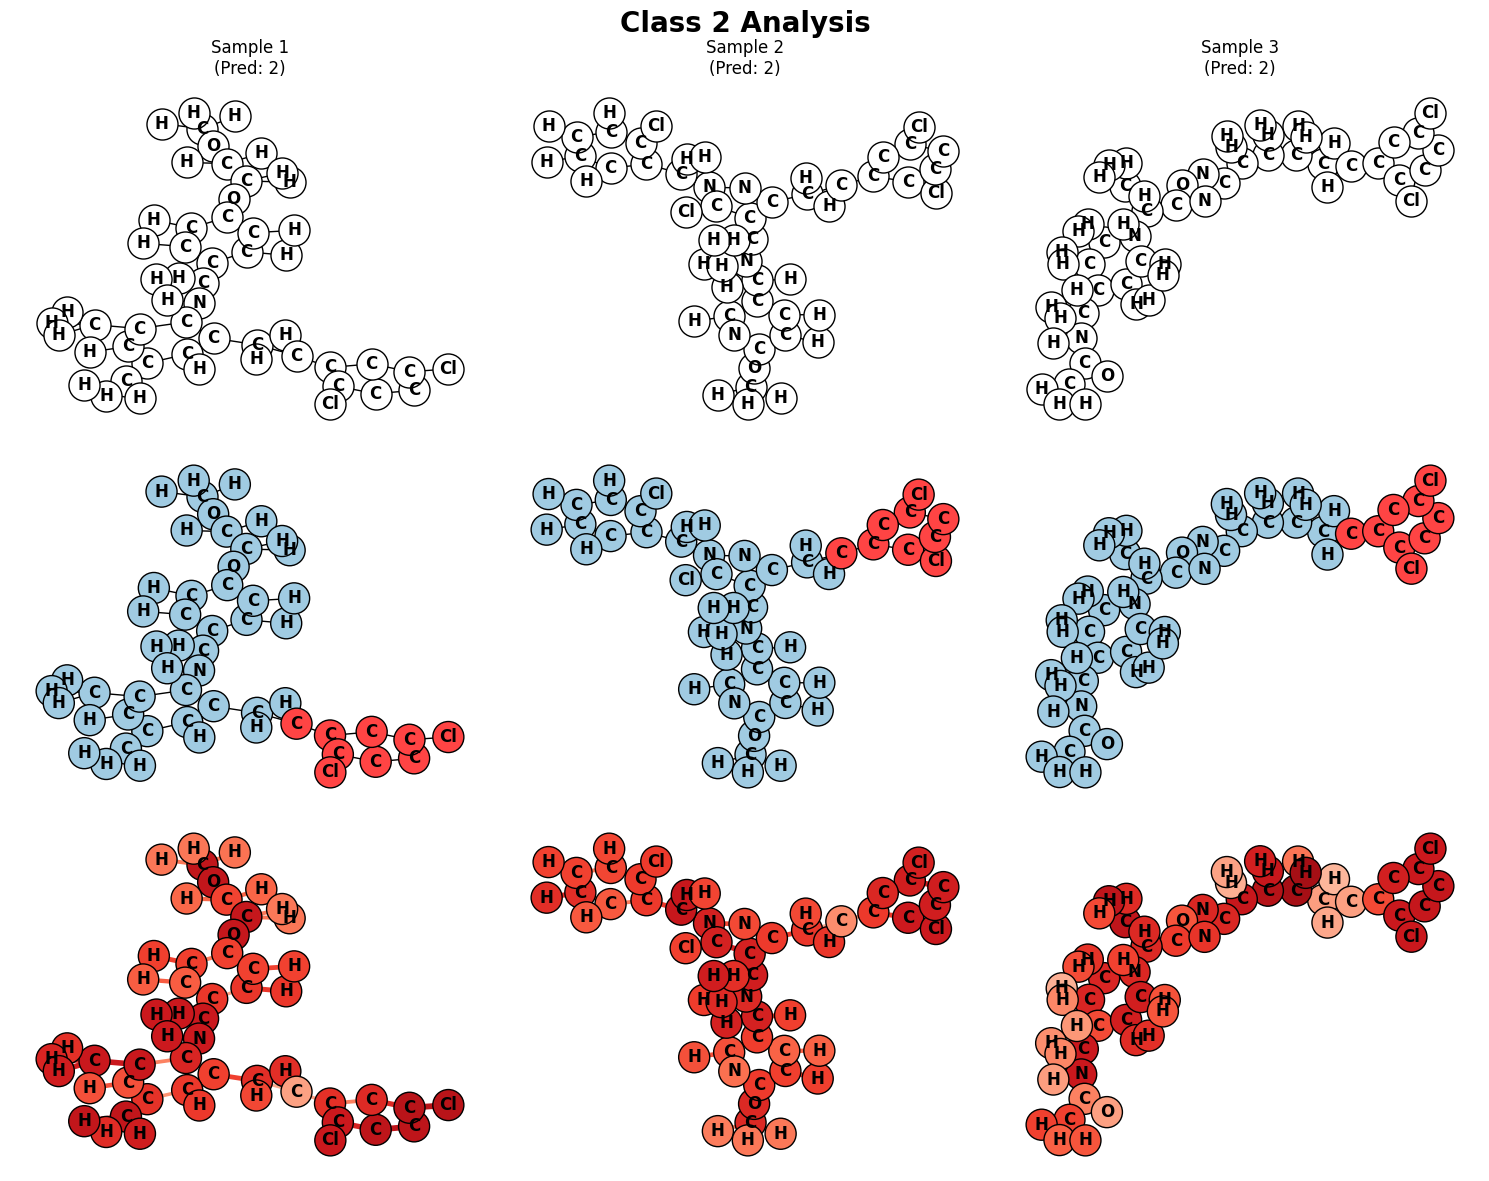


Generating plots for Class 3...


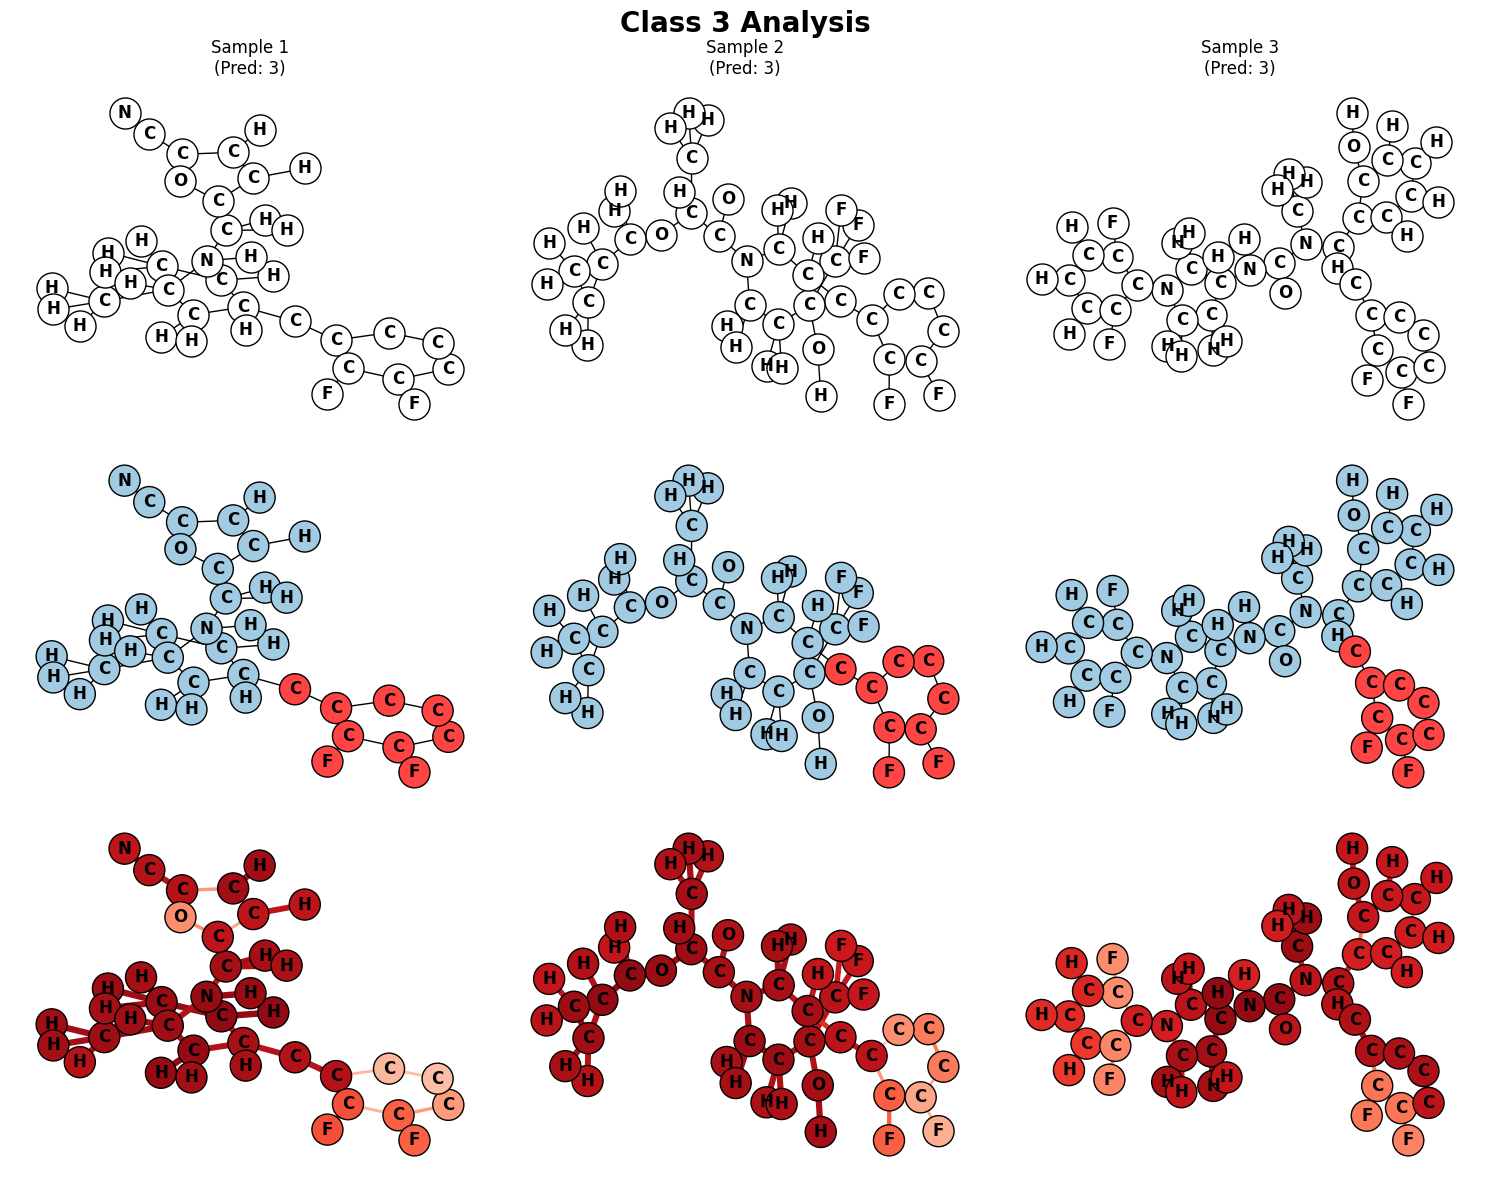


Generating plots for Class 4...


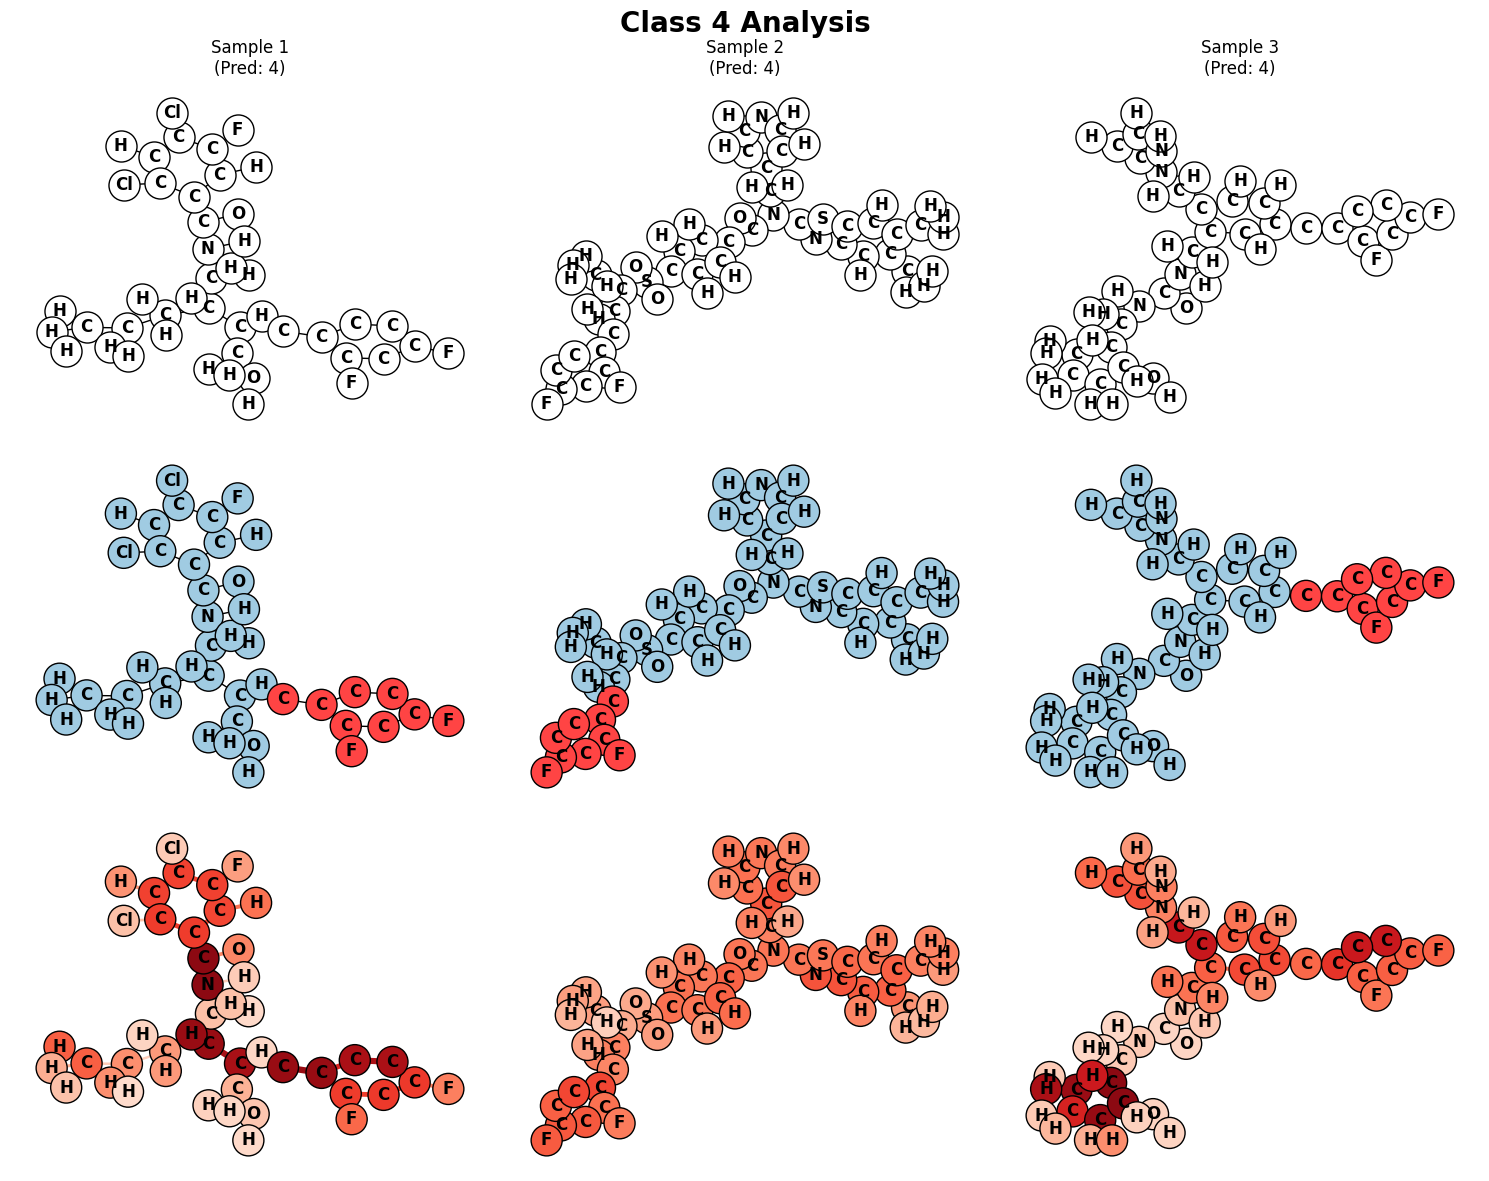


Generating plots for Class 5...


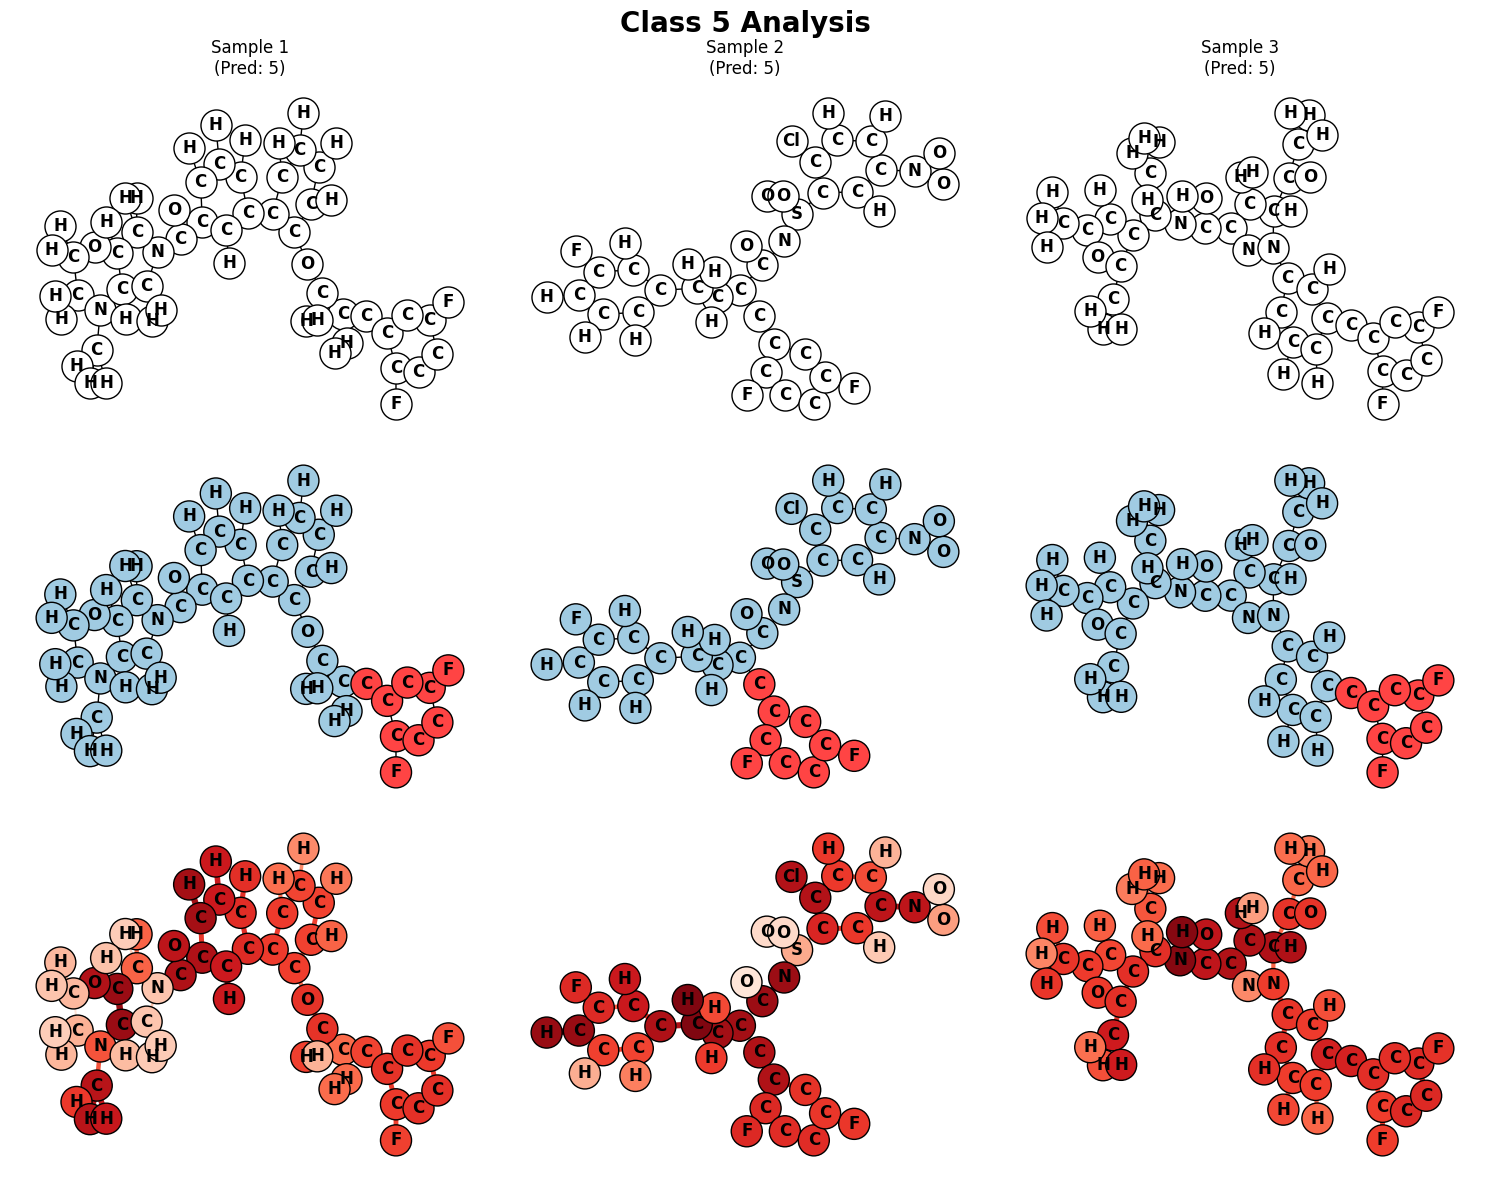


Generating plots for Class 6...


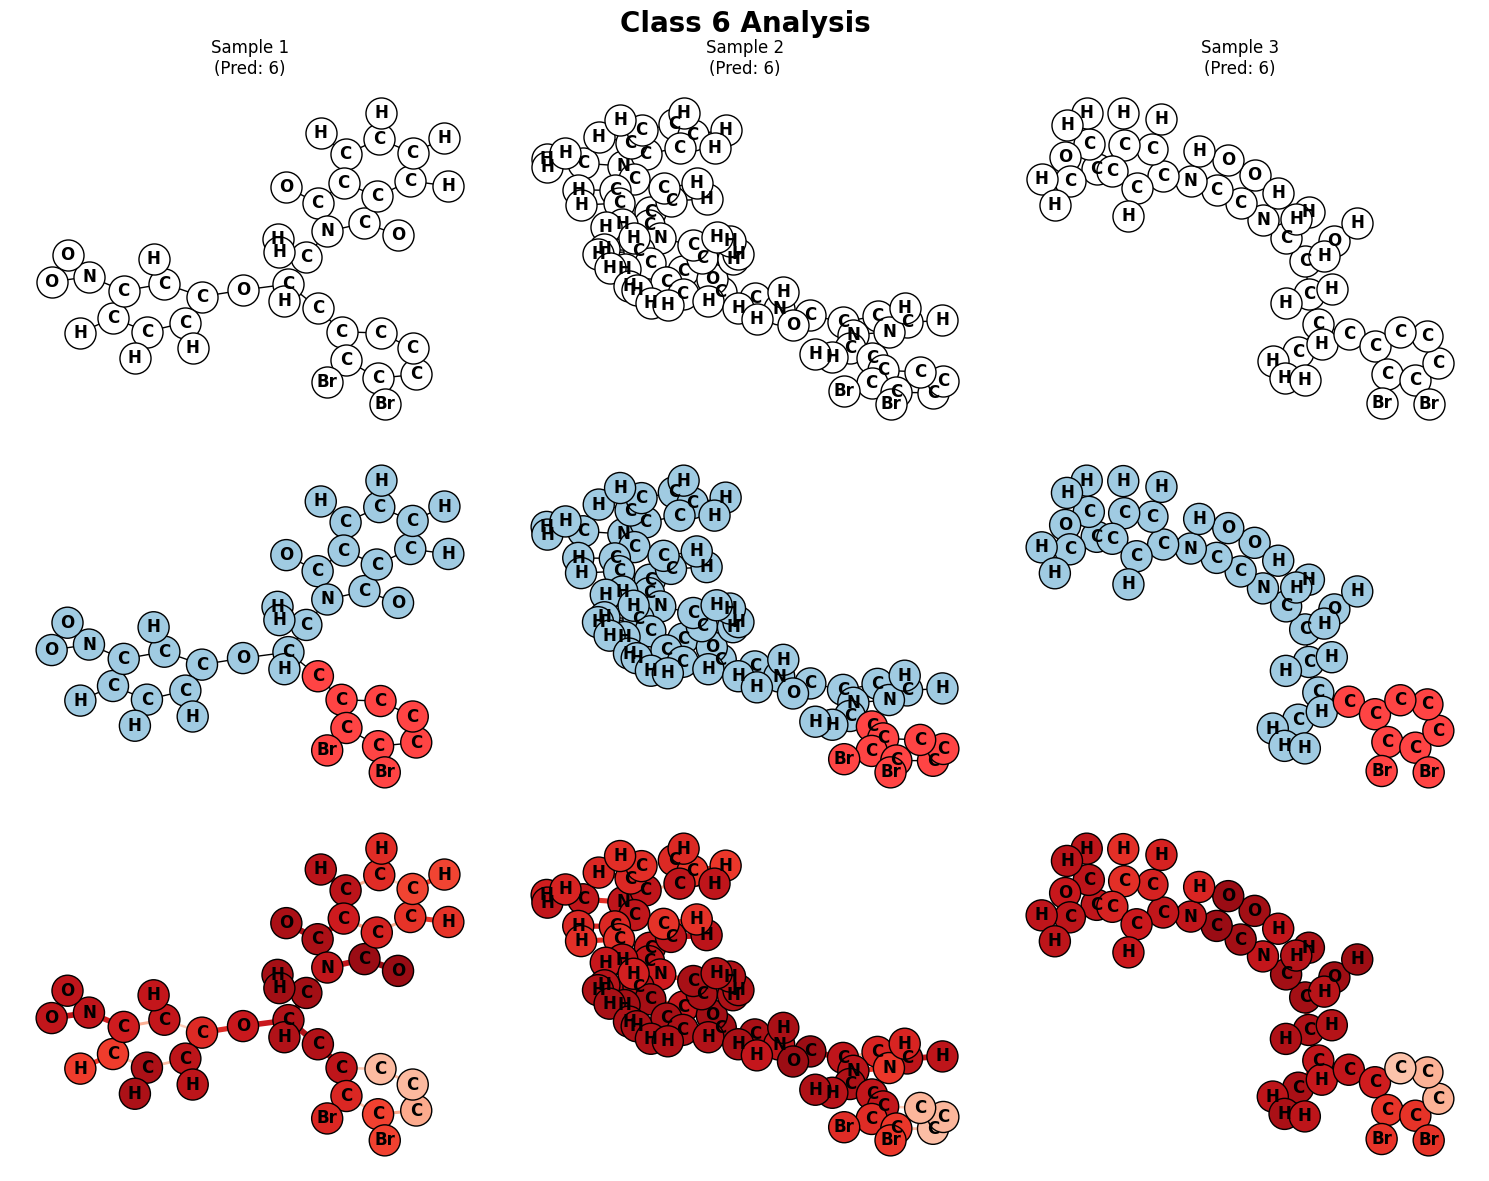


Generating plots for Class 7...


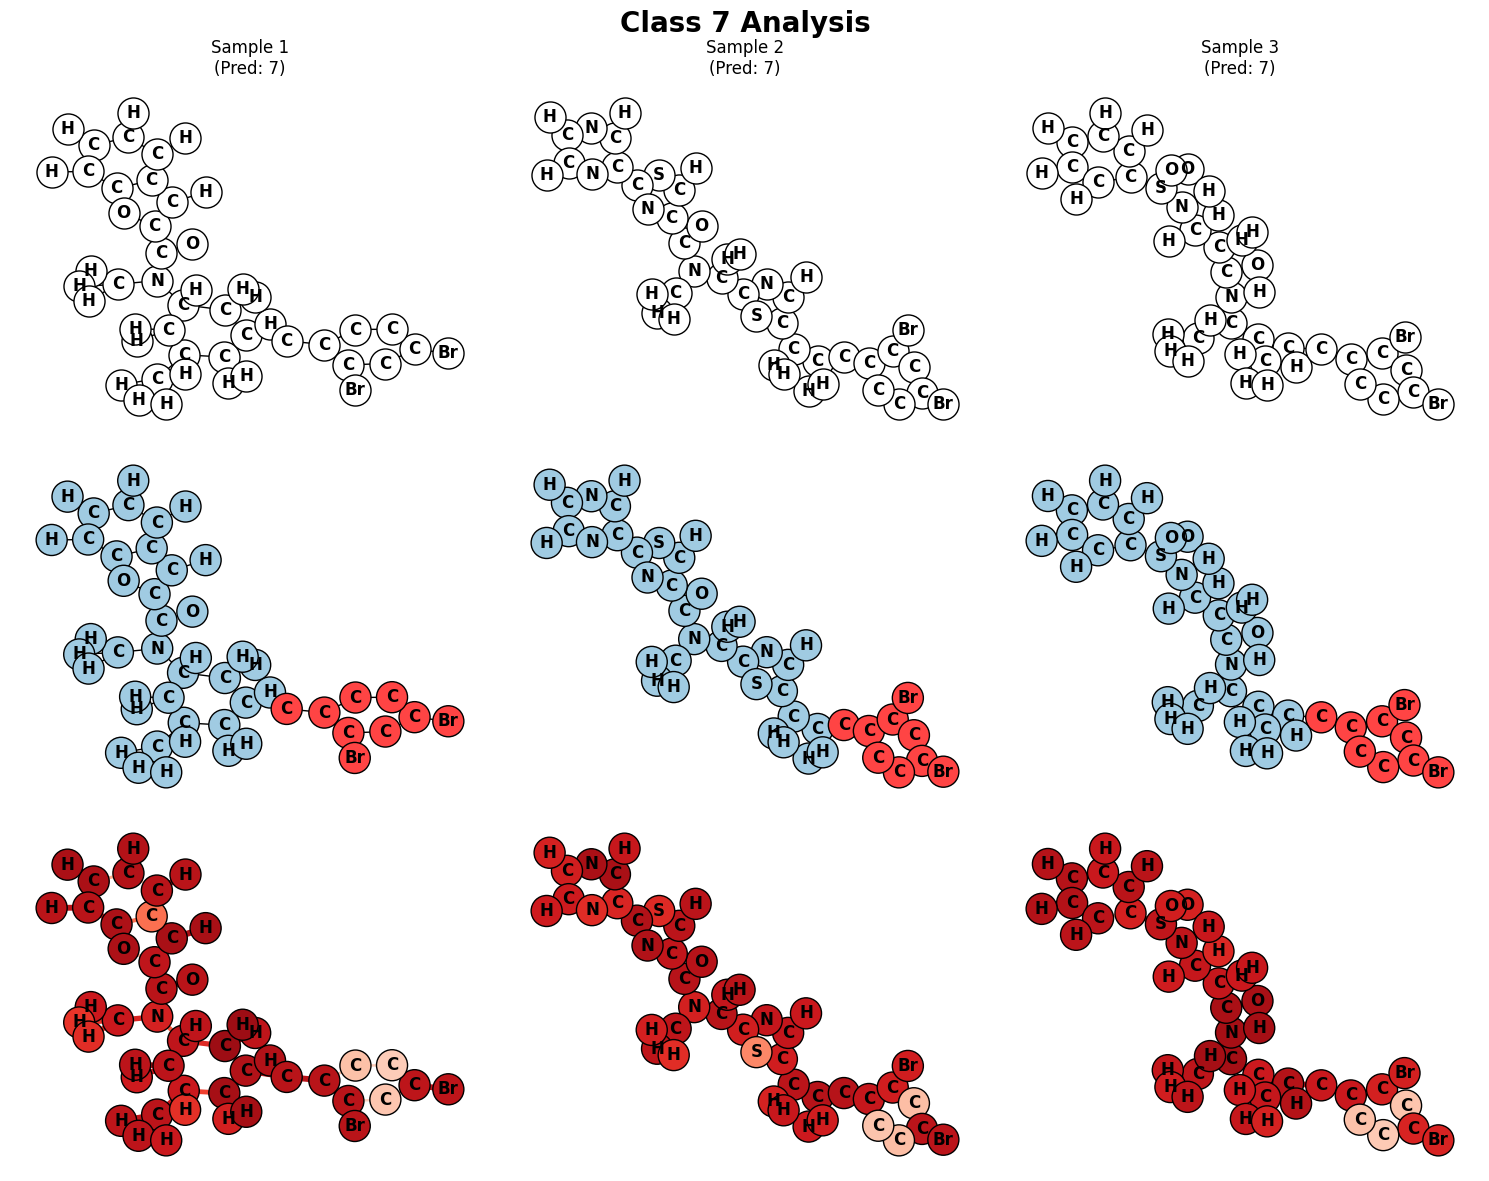


Generating plots for Class 8...


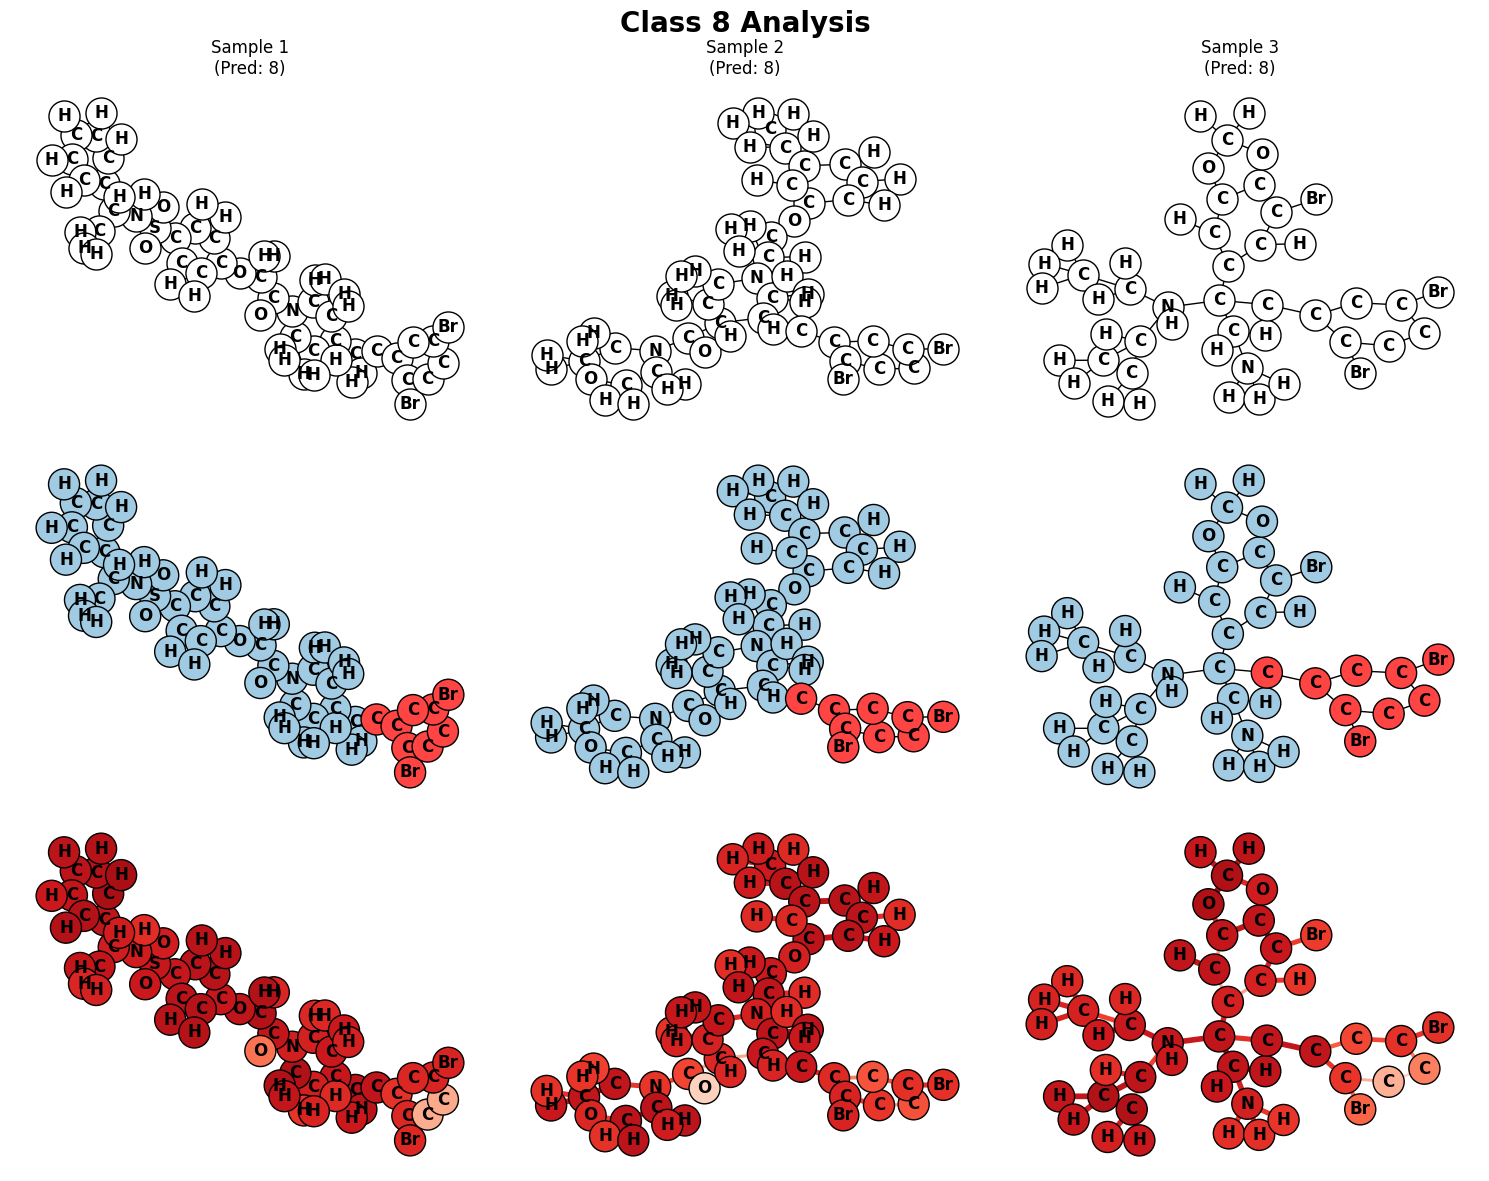

In [21]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx

# ------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------
permitted_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
ATOM_MAP = {i: atom for i, atom in enumerate(permitted_list)}
CLASSES_TO_SHOW = 9  # Assuming 9 classes (0-8)
SAMPLES_PER_CLASS = 3

# ------------------------------------------------------------------
# HELPER: Get Samples
# ------------------------------------------------------------------
def get_samples_for_class(dataset, c, num_samples=3):
    samples = []
    for data in dataset:
        y = data.y.item() if data.y.numel() == 1 else data.y[0].item()
        if y == c:
            samples.append(data)
            if len(samples) >= num_samples:
                break
    return samples

# ------------------------------------------------------------------
# MAIN VISUALIZATION FUNCTION
# ------------------------------------------------------------------
def visualize_all_classes(explainer, dataset, model, device, atom_map):
    model.eval()
    
    # Iterate over all classes
    for class_idx in range(CLASSES_TO_SHOW):
        print(f"\nGenerating plots for Class {class_idx}...")
        
        # Get 3 samples for this class
        samples = get_samples_for_class(dataset, class_idx, num_samples=SAMPLES_PER_CLASS)
        
        if not samples:
            print(f"No samples found for Class {class_idx}")
            continue

        # Prepare Figure: 3 Rows (Types), N Columns (Samples)
        fig, axes = plt.subplots(3, SAMPLES_PER_CLASS, figsize=(5 * SAMPLES_PER_CLASS, 12))
        fig.suptitle(f"Class {class_idx} Analysis", fontsize=20, fontweight='bold')
        
        # Headers for rows
        row_names = ["Original Molecule", "Ground Truth (Node Mask)", "GNN Prediction (Explainer)"]
        
        for col_idx, data in enumerate(samples):
            # -------------------------------------------------
            # PRE-PROCESSING
            # -------------------------------------------------
            data = data.to(device)
            
            # Run Model & Explainer
            output = model(data)
            pred_class = output.argmax(dim=1).item()
            
            explanation = explainer(
                x=data.x,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr,
                batch=torch.zeros(data.x.size(0), dtype=torch.long, device=device),
                target=torch.tensor(pred_class, device=device)
            )
            
            # Move to CPU
            data = data.cpu()
            explanation = explanation.cpu()
            edge_mask = explanation.edge_mask.detach().numpy()
            
            # Build Graph
            G = to_networkx(data, to_undirected=True)
            G.remove_edges_from(nx.selfloop_edges(G))
            pos = nx.kamada_kawai_layout(G) # Consistent layout for all 3 rows
            
            # Labels
            node_labels = {}
            for i, feat in enumerate(data.x):
                atom_idx = feat.argmax().item()
                node_labels[i] = atom_map.get(atom_idx, '?')

            # -------------------------------------------------
            # ROW 1: ORIGINAL MOLECULE
            # -------------------------------------------------
            ax = axes[0, col_idx] if SAMPLES_PER_CLASS > 1 else axes[0]
            nx.draw(G, pos, ax=ax, 
                    node_color='white', edgecolors='black', node_size=500,
                    with_labels=True, labels=node_labels, font_weight='bold')
            ax.set_title(f"Sample {col_idx+1}\n(Pred: {pred_class})")
            if col_idx == 0: ax.set_ylabel(row_names[0], fontsize=14, fontweight='bold')
            ax.axis('off')

            # -------------------------------------------------
            # ROW 2: GROUND TRUTH
            # -------------------------------------------------
            ax = axes[1, col_idx] if SAMPLES_PER_CLASS > 1 else axes[1]
            
            # Get Mask
            if hasattr(data, 'node_mask') and data.node_mask is not None:
                gt_mask = data.node_mask.numpy()
            elif hasattr(data, 'explanation_mask'):
                gt_mask = data.explanation_mask.numpy()
            else:
                gt_mask = np.zeros(data.num_nodes)

            # Colors: Red if 1, Light Blue if 0
            gt_colors = ['#ff4444' if m == 1 else '#a0cbe2' for m in gt_mask]
            
            nx.draw(G, pos, ax=ax,
                    node_color=gt_colors, edgecolors='black', node_size=500,
                    with_labels=True, labels=node_labels, font_weight='bold')
            
            if col_idx == 0: ax.set_ylabel(row_names[1], fontsize=14, fontweight='bold')
            ax.axis('off')

            # -------------------------------------------------
            # ROW 3: PREDICTED MOTIF
            # -------------------------------------------------
            ax = axes[2, col_idx] if SAMPLES_PER_CLASS > 1 else axes[2]
            
            # Derive Edge & Node Colors from Importance
            cmap = plt.cm.Reds
            norm = mcolors.Normalize(vmin=0, vmax=1)
            
            # Map edge weights
            u_list, v_list = data.edge_index[0].numpy(), data.edge_index[1].numpy()
            
            edge_colors = []
            edge_widths = []
            node_importance = np.zeros(data.num_nodes)
            
            for u, v in G.edges():
                # Match edge index
                mask_idx = (u_list == u) & (v_list == v)
                mask_idx_rev = (u_list == v) & (v_list == u)
                
                w = max(
                    edge_mask[mask_idx].max() if mask_idx.any() else 0,
                    edge_mask[mask_idx_rev].max() if mask_idx_rev.any() else 0
                )
                
                edge_colors.append(cmap(norm(w)))
                edge_widths.append(1.0 + 4.0 * w) # Thicker if important
                
                # Update node importance (max of incident edges)
                node_importance[u] = max(node_importance[u], w)
                node_importance[v] = max(node_importance[v], w)
            
            node_colors = [cmap(norm(s)) for s in node_importance]

            nx.draw(G, pos, ax=ax,
                    node_color=node_colors, edgecolors='black', node_size=500,
                    edge_color=edge_colors, width=edge_widths,
                    with_labels=True, labels=node_labels, font_weight='bold')
            
            if col_idx == 0: ax.set_ylabel(row_names[2], fontsize=14, fontweight='bold')
            ax.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.92) # Make room for suptitle
        plt.show()

# --- EXECUTE ---
visualize_all_classes(explainer, test_dataset, model, device, ATOM_MAP)

Explaining Molecule 19 (Class 0)...


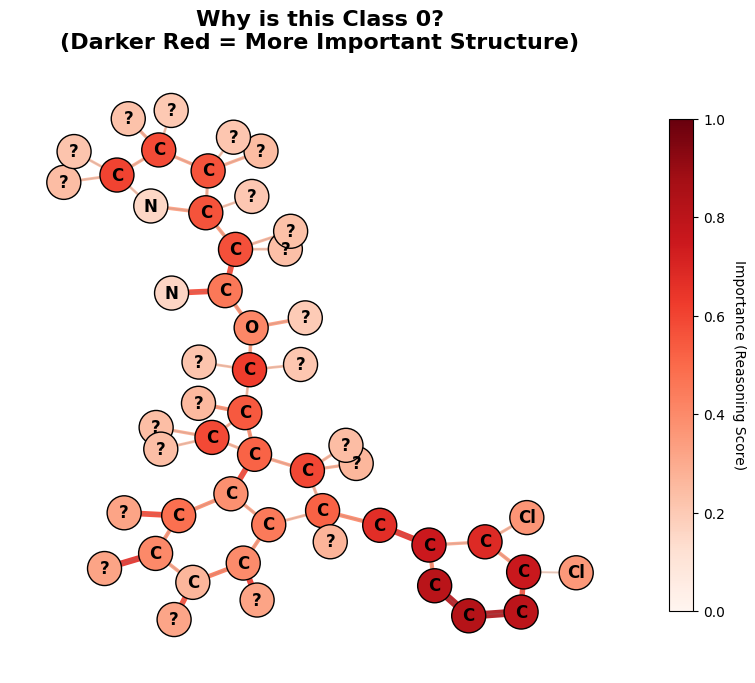

In [22]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import to_networkx

# ==========================================
# REFINED VISUALIZATION: Nodes + Edges
# ==========================================
def visualize_specific_reasoning(data, explanation, atom_mapping, title="Explanation"):
    # 1. Setup Graph
    G = to_networkx(data, to_undirected=True)
    pos = nx.kamada_kawai_layout(G) # Best layout for chemical topology without coords
    
    # 2. Extract Masks (The "Why")
    node_mask = explanation.node_mask.detach().cpu().numpy()
    edge_mask = explanation.edge_mask.detach().cpu().numpy()
    
    # 3. Setup Node Colors (Importance = Color Intensity)
    # We use a Red Colormap: White (0.0) -> Red (1.0)
    # This highlights the Halogen and the specific Carbon atoms involved
    node_cmap = plt.cm.Reds
    node_norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # Map node indices to their importance color
    node_colors = []
    for i in range(len(G.nodes)):
        # If node_mask is 1D or 2D, handle accordingly
        importance = node_mask[i].max() if len(node_mask.shape) > 1 else node_mask[i]
        node_colors.append(node_cmap(node_norm(importance)))

    # 4. Setup Edge Colors & Widths (The "Path")
    edge_colors = []
    edge_widths = []
    
    # Map edge_index to undirected NetworkX edges
    edge_weight_map = {}
    for i in range(data.edge_index.shape[1]):
        u = data.edge_index[0, i].item()
        v = data.edge_index[1, i].item()
        edge_weight_map[(u, v)] = edge_mask[i].item()
        edge_weight_map[(v, u)] = edge_mask[i].item()

    for u, v in G.edges():
        weight = edge_weight_map.get((u, v), 0.0)
        # Edges match the red theme: Dark Red for important bonds, faint for others
        edge_colors.append(node_cmap(node_norm(weight)))
        edge_widths.append(weight * 6 + 0.5) # Minimum width 0.5 so molecule stays visible

    # 5. Draw
    plt.figure(figsize=(10, 8))
    
    # A. Draw Edges (Bonds)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.9)
    # Draw faint outline for context (so you see the rest of the ring)
    nx.draw_networkx_edges(G, pos, width=1, edge_color='grey', alpha=0.2)
    
    # B. Draw Nodes (Atoms)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, edgecolors='black')
    
    # C. Label Atoms (Cl, F, C...)
    # Map one-hot encoded 'x' to labels
    labels = {}
    for i in range(data.num_nodes):
        atom_idx = data.x[i].argmax().item()
        labels[i] = atom_mapping.get(atom_idx, '?')
        
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight='bold')
    
    # D. Colorbar Legend
    sm = plt.cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    cbar.set_label('Importance (Reasoning Score)', rotation=270, labelpad=15)

    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

# ==========================================
# EXECUTION (Run this part)
# ==========================================

# 1. Setup Explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)

# 2. Define your atom mapping (from your dataset)
ATOM_MAP = {0: 'C', 1: 'O', 2: 'N', 3: '?', 4: 'F', 5: 'Cl', 6: 'Br'}

# 3. Find a sample to explain (e.g., Class 0 - Chlorine Ortho?)
# You can change this to find specific classes you care about
target_class = 0 
sample_idx = None
for i in range(len(test_dataset)):
    if test_dataset[i].y.item() == target_class:
        sample_idx = i
        break

if sample_idx is not None:
    data_sample = test_dataset[sample_idx].to(device)
    
    # Run Explainer
    print(f"Explaining Molecule {sample_idx} (Class {target_class})...")
    explanation = explainer(data_sample.x, data_sample.edge_index, edge_attr=data_sample.edge_attr)
    
    # Visualize
    visualize_specific_reasoning(
        data_sample, 
        explanation, 
        ATOM_MAP, 
        title=f"Why is this Class {target_class}?\n(Darker Red = More Important Structure)"
    )
else:
    print(f"No samples found for Class {target_class}")